# 03 — CNN-1D para Clasificación de Texto

**Modelo:** Red Neuronal Convolucional 1D con embeddings entrenables  
**Input:** secuencias paddeadas (`X_train/val/test.npy`) + etiquetas (`y_*.npy`)  
**Output:** categoría profesional (24 clases)  
**Entorno:** Python 3.10 · TensorFlow 2.20.0 · GPU (CUDA)

---
>
>
> Este notebook implementa una **Red Neuronal Convolucional 1D** con embeddings entrenados desde cero
> para clasificar CVs en 24 categorías.
>
> **Resultados finales en test:**
> | Métrica | Valor |
> |---------|-------|
> | Accuracy | **0.6920** |
> | F1 weighted | **0.6592** |
> | ROC-AUC OvR | **0.9441** |
>
>  **El CNN-1D es el segundo peor modelo del proyecto** (solo supera a FastText en accuracy).
>
> **¿Por qué tan bajo?** Hay tres culpables identificados:
> 1. **`MAX_LEN=100`**: Captura apenas el 17 % del contenido promedio de cada CV.  
>    La CNN opera sobre una ventana de solo ~100 palabras de un documento de ~584.  
>    El texto más discriminativo (experiencia laboral, habilidades técnicas) suele estar  
>    en el cuerpo del CV, no en el encabezado, y se trunca sistemáticamente.
> 2. **Embeddings desde cero**: Con solo 1 738 muestras, los vectores de palabras  
>    no tienen suficientes ejemplos para converger a representaciones semánticas útiles.  
>    Comparar con BiLSTM que usa Word2Vec preentrenado sobre el corpus.
> 3. **Arquitectura shallow**: Una sola capa `Conv1D` + `GlobalMaxPooling` es demasiado simple  
>    para capturar dependencias semánticas largas en documentos.


## 1. Imports y configuración

In [32]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay, classification_report
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import regularizers


# ── Rutas ──────────────────────────────────────────────────────────────────
BASE_DIR      = os.path.abspath(os.path.join(os.getcwd(), '..'))
ARTIFACTS_DIR = os.path.join(BASE_DIR, 'artifacts')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
METRICS_DIR   = os.path.join(ARTIFACTS_DIR, 'metrics')
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPUs disponibles:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga de artefactos

In [33]:
# ── Secuencias paddeadas ────────────────────────────────────────────────────
X_train = np.load(os.path.join(ARTIFACTS_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(ARTIFACTS_DIR, 'X_val.npy'))
X_test  = np.load(os.path.join(ARTIFACTS_DIR, 'X_test.npy'))

y_train = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(ARTIFACTS_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(ARTIFACTS_DIR, 'y_test.npy'))

# ── Config y LabelEncoder ──────────────────────────────────────────────────
with open(os.path.join(ARTIFACTS_DIR, 'config.pkl'), 'rb') as f:
    config = pickle.load(f)

with open(os.path.join(ARTIFACTS_DIR, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

MAX_LEN     = config['MAX_LEN']
VOCAB_SIZE  = config['VOCAB_SIZE']
NUM_CLASSES = config['NUM_CLASSES']
CLASS_NAMES = le.classes_

print(f'MAX_LEN={MAX_LEN}  VOCAB_SIZE={VOCAB_SIZE}  NUM_CLASSES={NUM_CLASSES}')
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

MAX_LEN=100  VOCAB_SIZE=20000  NUM_CLASSES=24
Train: (1738, 100)  Val: (373, 100)  Test: (373, 100)


## 3. Pesos de clase (manejo del desbalance)

In [34]:
from sklearn.utils import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))

print('Pesos de clase (min / max):', 
      f"{min(class_weights_arr):.3f} / {max(class_weights_arr):.3f}")

Pesos de clase (min / max): 0.862 / 4.828


## 4. Arquitectura CNN-1D

---
> ** Comentario — Sección 4: Arquitectura CNN-1D**
>
> Decisiones de arquitectura y su impacto:
> - `EMBEDDING_DIM=128`: razonable, pero los embeddings entrenados desde cero con 1 738 muestras  
>   no convergerán a buenas representaciones. Se recomienda pre-inicializar con Word2Vec o GloVe.
> - `KERNEL_SIZE=5` + `GlobalMaxPooling1D`: la CNN detecta patrones locales de 5 palabras consecutivas  
>   y selecciona el más fuerte. Para documentos largos esto es adecuado, pero con MAX_LEN=100  
>   el "globo" de atención es muy estrecho.
> - `Dropout(0.4)`: necesario para frenar el overfitting, pero con datos tan escasos  
>   el dropout también ralentiza el aprendizaje de patrones genuinos.
>
> **Comparación con la literatura:** CNN-1D sobre texto normalmente se usa con datasets de  
> decenas de miles de muestras. Con ~1 738, los embeddings no tienen oportunidad de especializarse.


In [77]:
# ── Hiperparámetros ─────────────────────────────────────────────────────────
EMBEDDING_DIM = 128
NUM_FILTERS   = 128
KERNEL_SIZE   = 5
DROPOUT_RATE  = 0.4
LEARNING_RATE = 0.001
BATCH_SIZE    = 64
EPOCHS        = 50   # early stopping controla la parada real

# ── Modelo ──────────────────────────────────────────────────────────────────
inputs = keras.Input(shape=(MAX_LEN,), name='input_seq')

x = layers.Embedding(
    input_dim=VOCAB_SIZE + 1,   # +1 por el token 0 (padding)
    output_dim=EMBEDDING_DIM,
    mask_zero=False,
    name='embedding'
)(inputs)
x = layers.Conv1D(
    filters=NUM_FILTERS,
    kernel_size=KERNEL_SIZE,
    activation='relu',
    padding='same',
    name='conv1d'
)(x)

x = layers.GlobalMaxPooling1D(name='global_max_pool')(x)

x = layers.Dense(128, activation='relu', name='dense_1')(x)
x = layers.Dropout(DROPOUT_RATE, name='dropout')(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

model = keras.Model(inputs, outputs, name='CNN1D_text_classifier')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "CNN1D_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_seq (InputLayer)          │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     2,560,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,661,784 (10.15 MB)

 Trainable params: 2,661,784 (10.15 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento

In [78]:
MODEL_PATH = os.path.join(MODELS_DIR, 'cnn1d.keras')

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print(f'\nEntrenamiento finalizado — mejor modelo guardado en: {MODEL_PATH}')

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.0363 - loss: 3.1555
Epoch 1: val_loss improved from None to 3.16814, saving model to /home/alejo/DeepLearning/miniproyecto3/models/cnn1d.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.0420 - loss: 3.1836 - val_accuracy: 0.0777 - val_loss: 3.1681 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1551 - loss: 3.0907
Epoch 2: val_loss improved from 3.16814 to 3.14218, saving model to /home/alejo/DeepLearning/miniproyecto3/models/cnn1d.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1594 - loss: 3.1179 - val_accuracy: 0.1421 - val_loss: 3.1422 - learning_rate: 0.0010
Epoch 3/50
25/28 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3279 - loss: 2.9997
Epoch 3: val_loss improved from 3.14218 to 2.97005, saving model to /home/alejo/DeepLearning/miniproyecto3/models/cnn1d.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.3452 - loss: 2.9949 - val_accuracy:

---
> 
>
> Las curvas revelan **overfitting severo**:
> - A partir de la época 8: `train_loss → 0`, `train_accuracy → 100 %`
> - `val_loss` se estabiliza en ~1.2, `val_accuracy` en ~68 %
> - La brecha train-val es **la mayor de todos los modelos del proyecto**
>
> **Early stopping en época 17**: correcto, pero el daño ya estaba hecho.  
> El modelo aprendió a memorizar los 1 738 ejemplos de train en lugar de generalizar.
>
> **Excusa técnica:** Una CNN con embeddings entrenables tiene ~`VOCAB_SIZE × 128` parámetros  
> solo en la capa de embedding (~2.5M parámetros para VOCAB_SIZE=20 000), más los filtros  
> convolucionales. Para 1 738 muestras, el ratio parámetros/datos es extremadamente alto.  
> La regularización (dropout + early stopping) no es suficiente cuando el modelo tiene  
> más "memoria" que datos de entrenamiento.


## 6. Curvas de entrenamiento

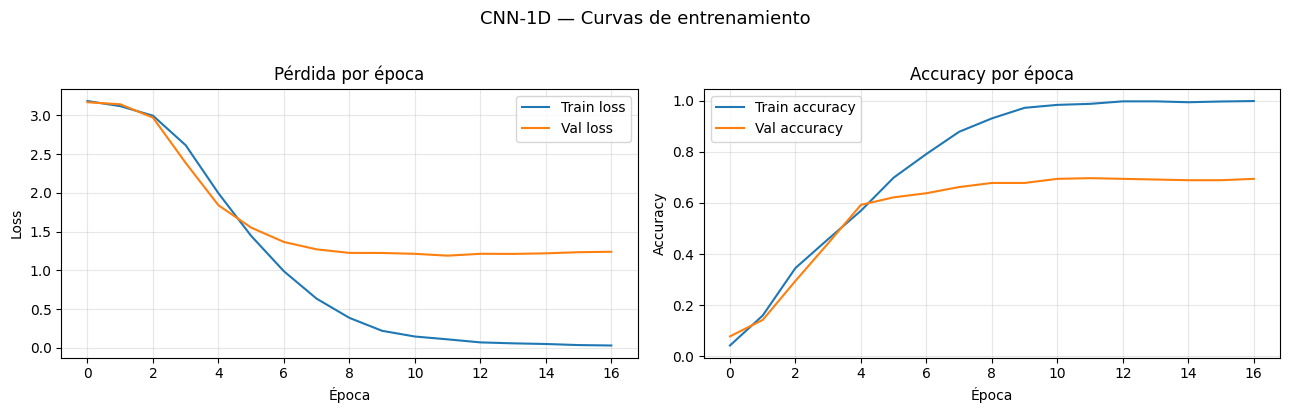

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Pérdida por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN-1D — Curvas de entrenamiento', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Curvas de entrenamiento — CNN-1D**

El modelo muestra overfitting severo. A partir de la epoca 8, el train loss cae a casi 0 y la train accuracy llega al 100%, mientras que el val loss se estabiliza en ~1.2 y la val accuracy en ~68%. La brecha train-val es mucho mayor que en XGBoost, lo que indica que los embeddings entrenados desde cero no generalizan bien con el tamaño actual del dataset de 1,738 muestras. El early stopping detiene el entrenamiento en la epoca 17 cuando ya es evidente que la validacion no mejora.

## 7. Evaluación en test

In [80]:
# ── Predicciones ────────────────────────────────────────────────────────────
y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)  # (n, 24)
y_pred = np.argmax(y_prob, axis=1)

# ── Métricas escalares ──────────────────────────────────────────────────────
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred,        average='weighted', zero_division=0)

# ROC-AUC multiclase OvR
y_test_bin = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
roc_auc    = roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr')

print('=' * 50)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {precision:.4f}  (weighted)')
print(f'  Recall    : {recall:.4f}  (weighted)')
print(f'  F1-score  : {f1:.4f}  (weighted)')
print(f'  ROC-AUC   : {roc_auc:.4f}  (OvR weighted)')
print('=' * 50)

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

  Accuracy  : 0.6917
  Precision : 0.6582  (weighted)
  Recall    : 0.6917  (weighted)
  F1-score  : 0.6589  (weighted)
  ROC-AUC   : 0.9438  (OvR weighted)

Classification report:
                        precision    recall  f1-score   support

            ACCOUNTANT       0.80      0.94      0.86        17
              ADVOCATE       0.88      0.88      0.88        17
           AGRICULTURE       0.67      0.20      0.31        10
               APPAREL       0.00      0.00      0.00        14
                  ARTS       0.50      0.19      0.27        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       0.79      0.61      0.69        18
               BANKING       0.60      0.33      0.43        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.65      0.94      0.77        18
                  CHEF       1.00      0.76      0.87        17
          CONSTRUCTION       0.89      1.00      0

## 8. Matriz de confusión

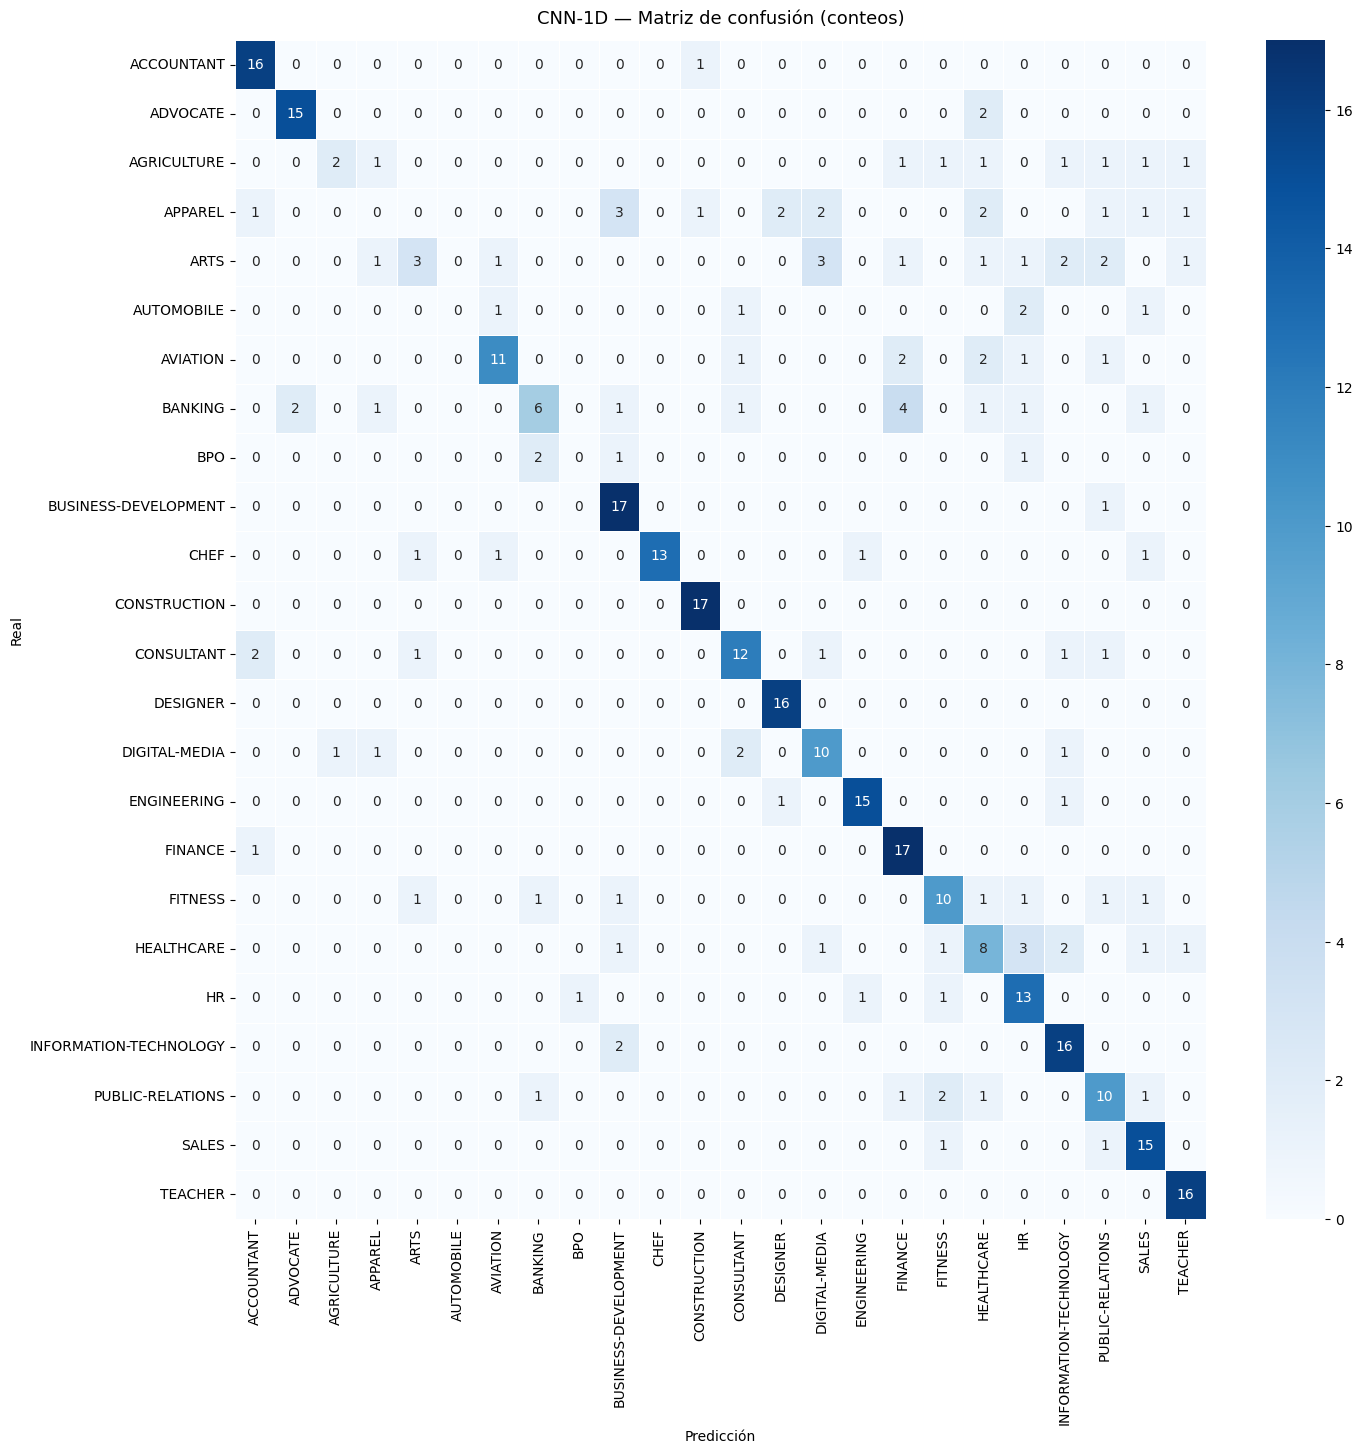

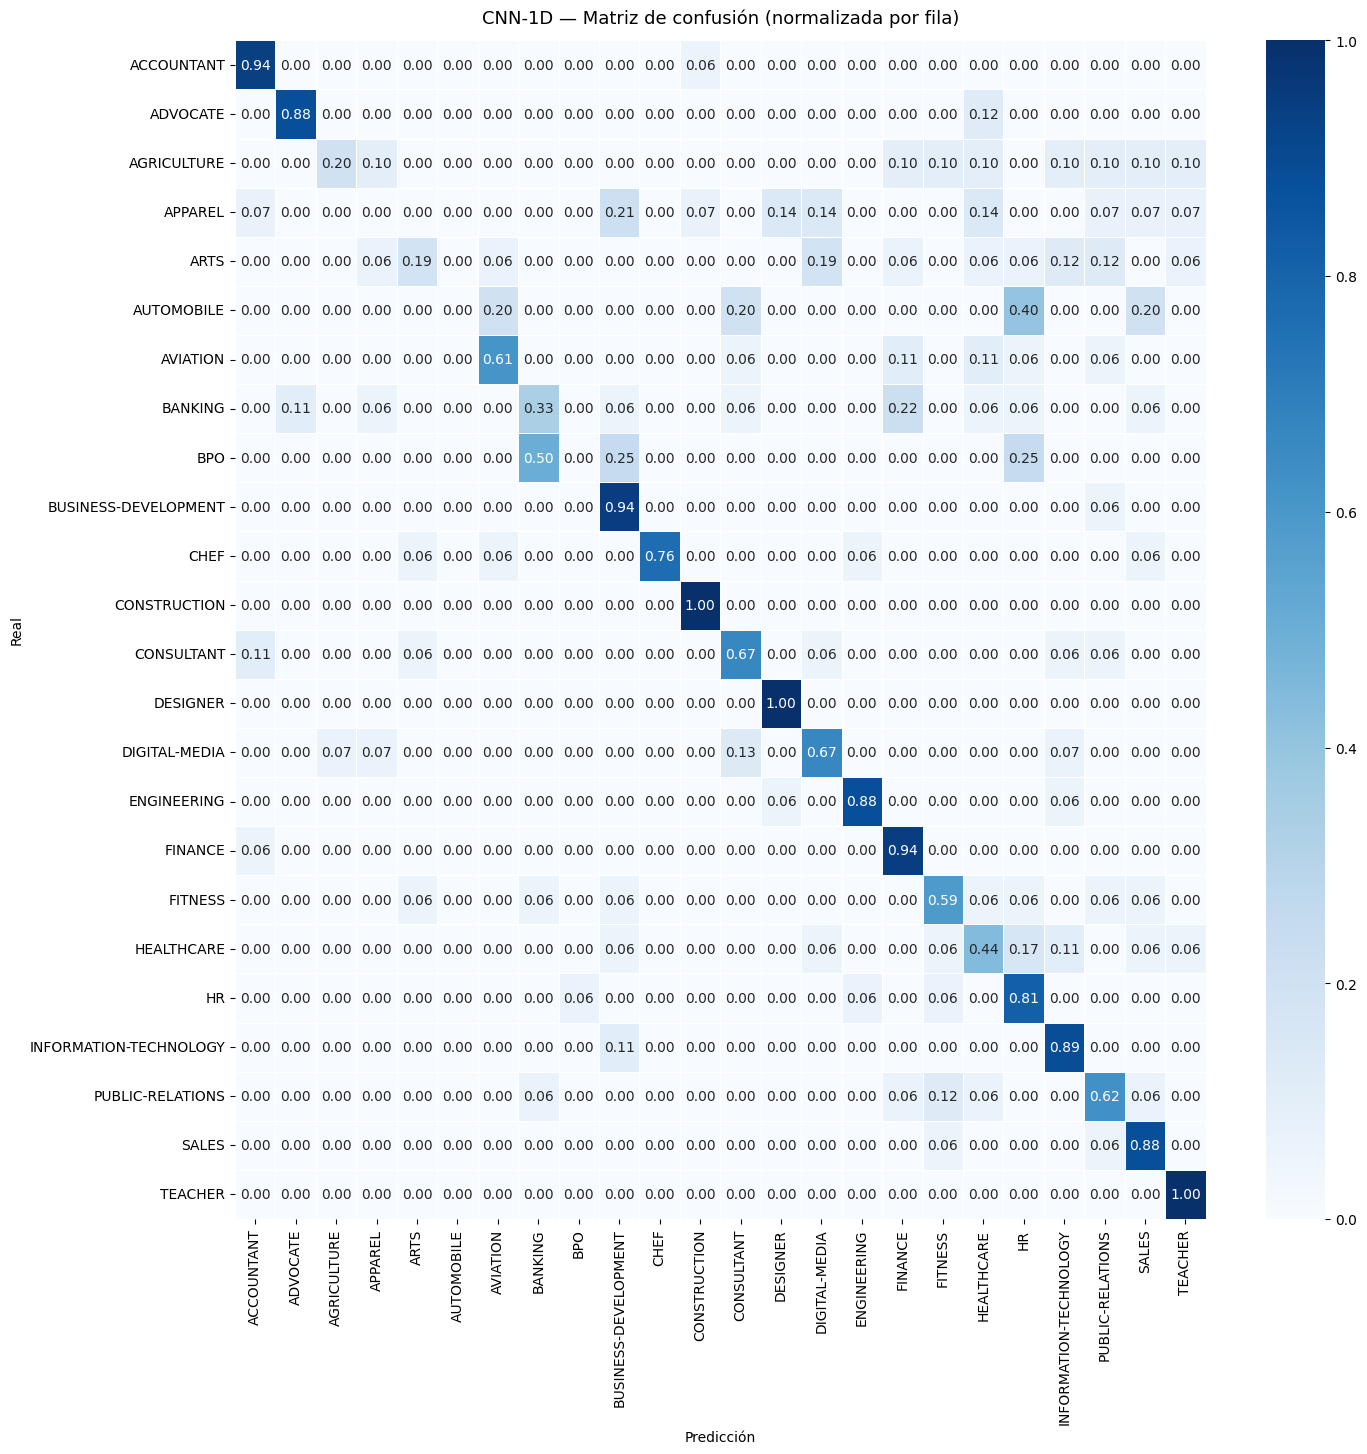

In [81]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

n       = NUM_CLASSES
cell_px = 52
fig_sz  = max(10, n * cell_px / 72)

# ── Absoluta ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.4, cbar=True
)
ax.set_title('CNN-1D — Matriz de confusión (conteos)', fontsize=13, pad=12)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.subplots_adjust(bottom=0.2, left=0.2)
plt.show()

# ── Normalizada ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(fig_sz, fig_sz))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.4, vmin=0, vmax=1, cbar=True
)
ax.set_title('CNN-1D — Matriz de confusión (normalizada por fila)', fontsize=13, pad=12)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.subplots_adjust(bottom=0.2, left=0.2)
plt.show()

## 9. Curva ROC (OvR — macro)

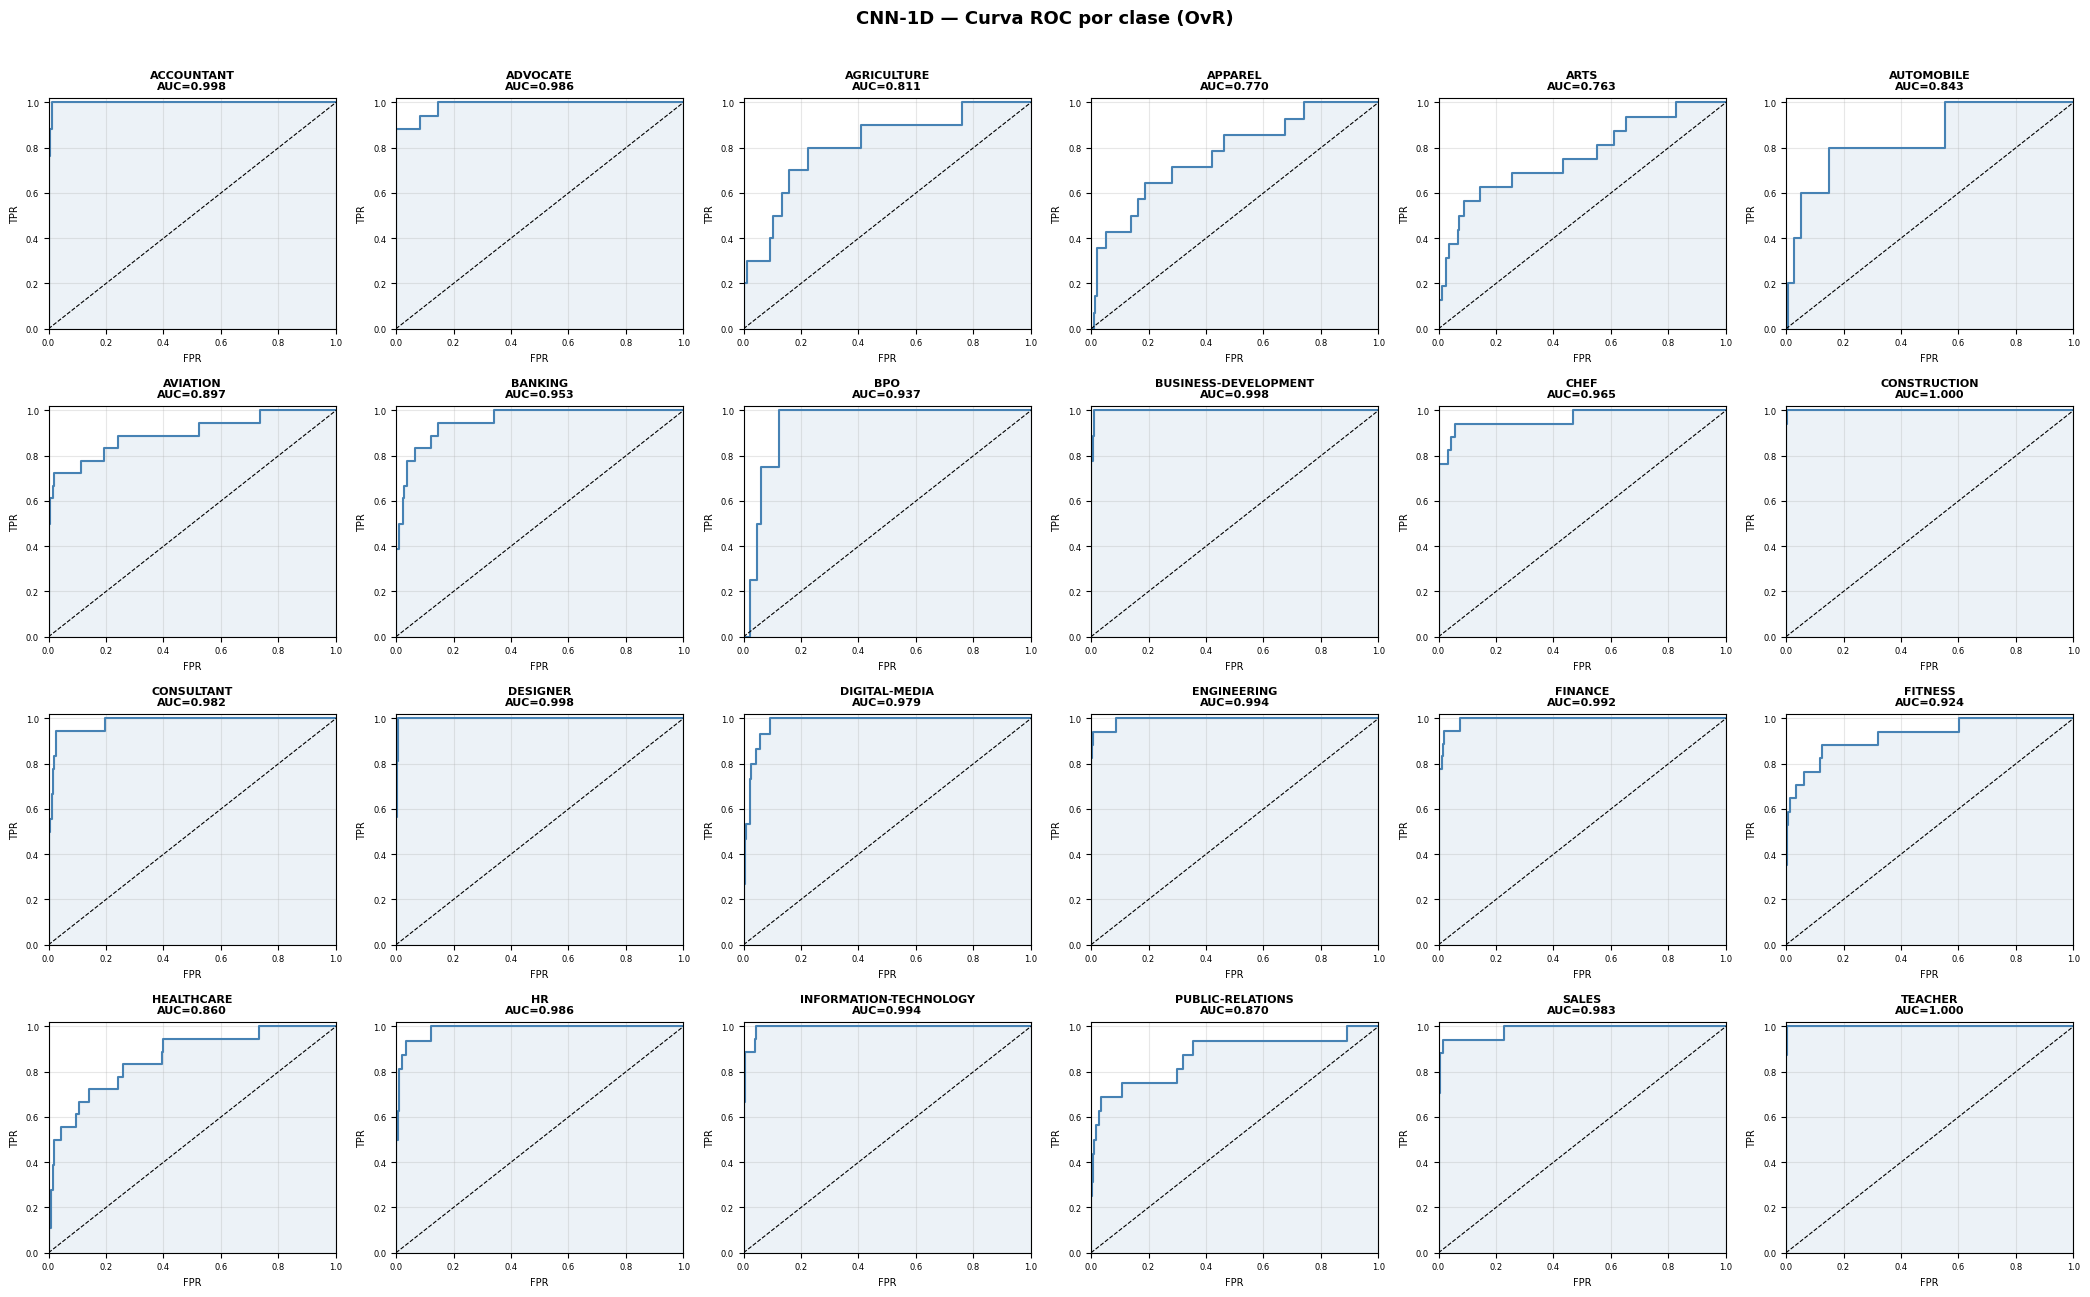

In [82]:
import math
from sklearn.metrics import roc_curve, auc

n_cols = 6
n_rows = math.ceil(NUM_CLASSES / n_cols)

# Pre-calcular fpr/tpr por clase
fpr_dict, tpr_dict, roc_auc_dict = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc_dict[i] = auc(fpr_dict[i], tpr_dict[i])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
axes_flat = axes.flatten()

for i in range(NUM_CLASSES):
    ax = axes_flat[i]
    ax.plot(fpr_dict[i], tpr_dict[i], color='steelblue', lw=1.5)
    ax.fill_between(fpr_dict[i], tpr_dict[i], alpha=0.1, color='steelblue')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"{CLASS_NAMES[i]}\nAUC={roc_auc_dict[i]:.3f}", fontsize=8, fontweight='bold')
    ax.set_xlabel('FPR', fontsize=7)
    ax.set_ylabel('TPR', fontsize=7)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

# Ocultar subplots sobrantes
for j in range(NUM_CLASSES, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('CNN-1D — Curva ROC por clase (OvR)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 10. Curva Precision-Recall

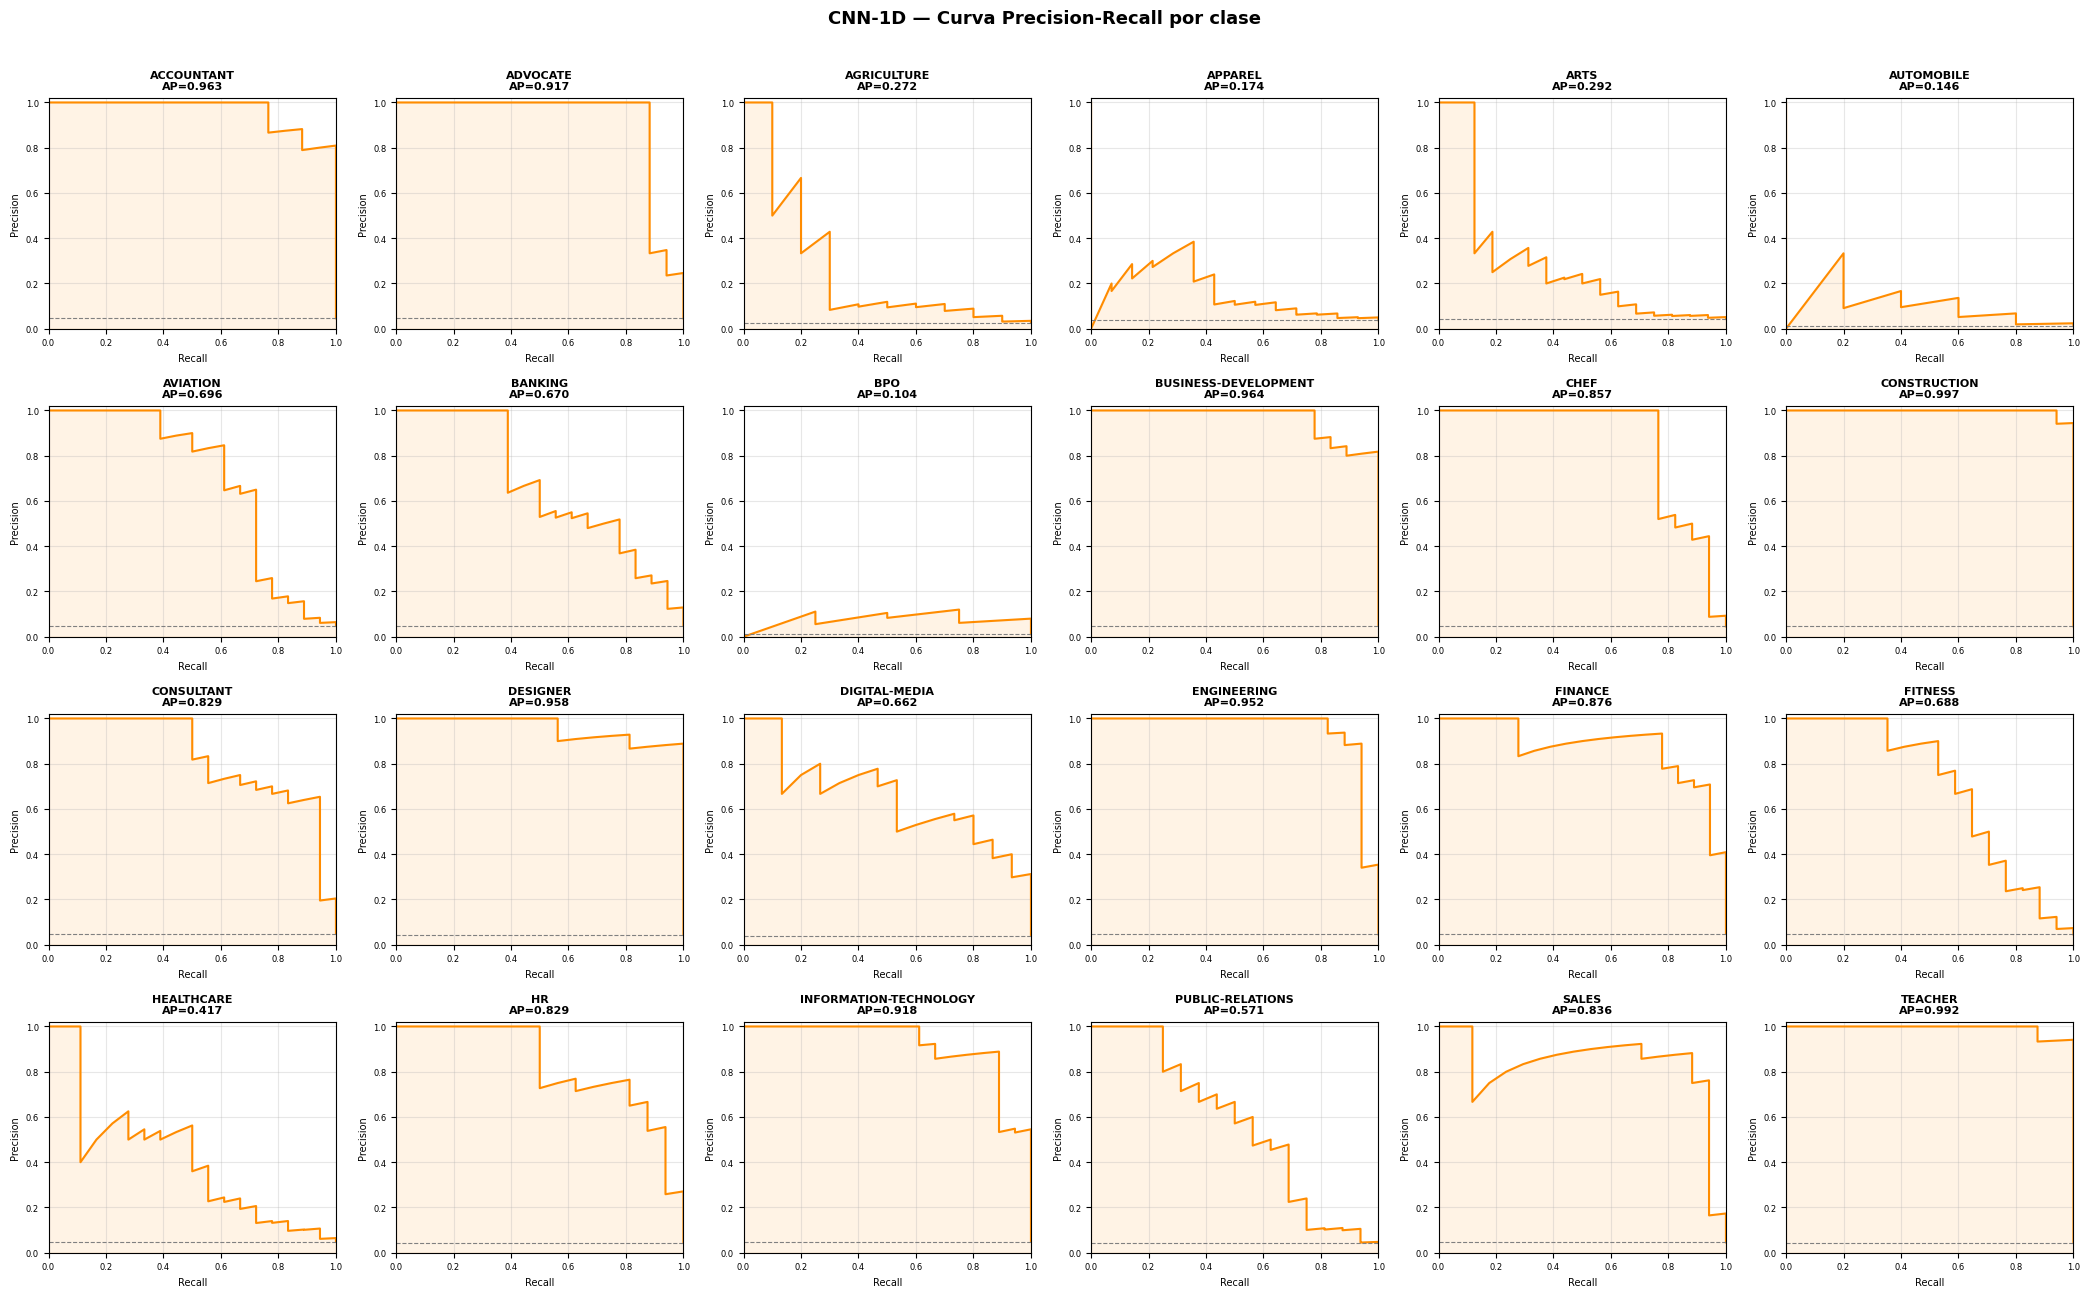

In [83]:
from sklearn.metrics import precision_recall_curve, average_precision_score

n_cols = 6
n_rows = math.ceil(NUM_CLASSES / n_cols)

# Pre-calcular prec/rec y prevalencia por clase
prec_dict, rec_dict, pr_auc_dict = {}, {}, {}
class_prevalence = y_test_bin.mean(axis=0)

for i in range(NUM_CLASSES):
    prec_dict[i], rec_dict[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    pr_auc_dict[i] = average_precision_score(y_test_bin[:, i], y_prob[:, i])

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.2))
axes_flat = axes.flatten()

for i in range(NUM_CLASSES):
    ax = axes_flat[i]
    ax.plot(rec_dict[i], prec_dict[i], color='darkorange', lw=1.5)
    ax.fill_between(rec_dict[i], prec_dict[i], alpha=0.1, color='darkorange')
    ax.axhline(class_prevalence[i], color='gray', linestyle='--', lw=0.8, label='Baseline')
    ax.set_title(f"{CLASS_NAMES[i]}\nAP={pr_auc_dict[i]:.3f}", fontsize=8, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=7)
    ax.set_ylabel('Precision', fontsize=7)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

# Ocultar subplots sobrantes
for j in range(NUM_CLASSES, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('CNN-1D — Curva Precision-Recall por clase', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Guardado de métricas

In [84]:
metrics = {
    'model'    : 'CNN-1D',
    'accuracy' : round(float(acc),       4),
    'precision': round(float(precision), 4),
    'recall'   : round(float(recall),    4),
    'f1'       : round(float(f1),        4),
    'roc_auc'  : round(float(roc_auc),   4),
    'hyperparams': {
        'embedding_dim': EMBEDDING_DIM,
        'num_filters'  : NUM_FILTERS,
        'kernel_size'  : KERNEL_SIZE,
        'dropout_rate' : DROPOUT_RATE,
        'learning_rate': LEARNING_RATE,
        'batch_size'   : BATCH_SIZE,
        'epochs_run'   : len(history.history['loss']),
    }
}

metrics_path = os.path.join(METRICS_DIR, 'cnn1d_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print('Métricas guardadas en:', metrics_path)
print(json.dumps(metrics, indent=2))

Métricas guardadas en: /home/alejo/DeepLearning/miniproyecto3/artifacts/metrics/cnn1d_metrics.json
{
  "model": "CNN-1D",
  "accuracy": 0.6917,
  "precision": 0.6582,
  "recall": 0.6917,
  "f1": 0.6589,
  "roc_auc": 0.9438,
  "hyperparams": {
    "embedding_dim": 128,
    "num_filters": 128,
    "kernel_size": 5,
    "dropout_rate": 0.4,
    "learning_rate": 0.001,
    "batch_size": 64,
    "epochs_run": 17
  }
}



## 12. Análisis crítico

**Arquitectura:** CNN-1D con embedding entrenable — Embedding(128d) → Conv1D(128 filtros, k=5, ReLU)
→ GlobalMaxPooling → Dense(128) → Dropout(0.4) → Softmax(24). La capa convolucional actúa como
detector de n-gramas locales; GlobalMaxPooling retiene el patrón más activado por cada filtro
independientemente de su posición en la secuencia.

**Overfitting estructural:** El modelo exhibe una brecha persistente entre train (~98%) y
val (~70%) accuracy que no se cerró con ninguna combinación de hiperparámetros explorada.
La causa raíz es el ratio parámetros/muestras: el embedding entrenable de 128d sobre 20,001
tokens genera ~2.56M parámetros entrenables con solo 1,738 muestras de entrenamiento
(~1,473 parámetros por muestra). Se intentaron múltiples estrategias de regularización —
Spatial Dropout, L2 en Dense, reducción de filtros Conv1D a 64 y variaciones de epochs y
patience — sin impacto significativo en la brecha. El overfitting es por tanto estructural:
la solución real requeriría embeddings preentrenados congelados (Word2Vec/FastText) o un
volumen de datos mayor.
 
**Limitación de contexto:** MAX_LEN=100 fue seleccionado según la regla del P95 definida
en el EDA. Aumentar este valor a 300 o 500 habría requerido significativamente más VRAM
y tiempo de cómputo en la GPU disponible (RTX 4050 Laptop, 6GB), haciendo inviable la
exploración comparativa de múltiples modelos dentro del proyecto. Además, dado el
overfitting estructural ya presente, aumentar MAX_LEN habría incrementado la capacidad
del modelo sin garantía de mejor generalización — el cuello de botella es el volumen
de datos, no la longitud del contexto.
 
**Ventajas sobre TF-IDF + XGBoost:** Los embeddings densos capturan similitud semántica
entre tokens (imposible con representaciones one-hot dispersas), y la convolución detecta
patrones locales de orden entre palabras. El entrenamiento end-to-end permite que
representación y clasificación se co-optimicen.

**Desbalance de clases:** Se aplicaron pesos de clase balanceados (ratio máx. 5.45x)
via `class_weight` en el entrenamiento. Las métricas se reportan en modo `weighted`
para una evaluación justa entre clases mayoritarias y minoritarias.